In [1]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

num_cpus = 5

### Load chromosome arms data

In [2]:
mm10_arms = pd.read_csv('mm10_arms.csv', index_col=0)
mm10_arms.head(30)

,chrom,start,end,name
0,chr1,0,195471971,chr1_p
1,chr2,0,182113224,chr2_p
2,chr3,0,160039680,chr3_p
3,chr4,0,156508116,chr4_p
4,chr5,0,151834684,chr5_p
5,chr6,0,149736546,chr6_p
6,chr7,0,145441459,chr7_p
7,chr8,0,129401213,chr8_p
8,chr9,0,124595110,chr9_p
9,chr10,0,130694993,chr10_p


### Calculate expected across all groups (1kb, 10kb, replicates)

In [3]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import cooler
import cooltools
 
num_cpus = 5
 
mm10_arms = pd.read_csv('mm10_arms.csv', index_col=0)
 
# upload data
cooler_groups = {
    "1kb": {
        "colors": {"Adult": "tan", "Old": "sienna", "S6-KO": "gray27"},
        "levels": ["Adult", "Old", "S6-KO"],
        "clrs": {
            "Adult": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/combined/bal_sampled_Adult_1k.cool"),
            "Old":   cooler.Cooler("/tank/projects/kashuk_sirt6_hic/combined/bal_sampled_Old_1k.cool"),
            "S6-KO": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/combined/bal_sampled_S6-KO_1k.cool"),
        },
    },
    "10kb": {
        "colors": {"Adult": "tan", "Old": "sienna", "S6-KO": "gray27"},
        "levels": ["Adult", "Old", "S6-KO"],
        "clrs": {
            "Adult": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/bal_comb_10k/bal_sampled_WT_10k.cool"),
            "Old":   cooler.Cooler("/tank/projects/kashuk_sirt6_hic/bal_comb_10k/bal_sampled_old_10k.cool"),
            "S6-KO": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/bal_comb_10k/bal_sampled_KO_10k.cool"),
        },
    },
    "rep_s6ko": {
        "colors": {"S6-KO-1": "red", "S6-KO-2": "blue", "S6-KO-3": "gold"},
        "levels": ["S6-KO-1", "S6-KO-2", "S6-KO-3"],
        "clrs": {
            "S6-KO-1": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/balanced_10k/bal_sampled_KO_m_1_10k.cool"),
            "S6-KO-2": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/balanced_10k/bal_sampled_KO_f_2_10k.cool"),
            "S6-KO-3": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/balanced_10k/bal_sampled_KO_f_3_10k.cool"),
        },
    },
    "rep_adult": {
        "colors": {"Adult-1": "tan", "Adult-2": "peru", "Adult-3": "burlywood"},
        "levels": ["Adult-1", "Adult-2", "Adult-3"],
        "clrs": {
            "Adult-1": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/balanced_10k/bal_sampled_adl_m_1_10k.cool"),
            "Adult-2": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/balanced_10k/bal_sampled_adl_f_2_10k.cool"),
            "Adult-3": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/balanced_10k/bal_sampled_adl_f_3_10k.cool"),
        },
    },
    "rep_old": {
        "colors": {"Old-1": "sienna", "Old-2": "saddlebrown", "Old-3": "chocolate"},
        "levels": ["Old-1", "Old-2", "Old-3"],
        "clrs": {
            "Old-1": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/balanced_10k/bal_sampled_old_m_1_10k.cool"),
            "Old-2": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/balanced_10k/bal_sampled_old_f_2_10k.cool"),
            "Old-3": cooler.Cooler("/tank/projects/kashuk_sirt6_hic/balanced_10k/bal_sampled_old_f_3_10k.cool"),
        },
    },
}
 
# calculate expected for all groups
all_combined = {}
 
for group_name, group in cooler_groups.items():
    print(f"Processing {group_name}...")
    frames = []
    for name, clr in group["clrs"].items():
        cvd = cooltools.expected_cis(
            clr=clr,
            view_df=mm10_arms,
            smooth=True,
            aggregate_smoothed=True,
            smooth_sigma=0.1,
            nproc=num_cpus,
        )
        cvd["balanced.avg.smoothed.agg"].loc[cvd["dist"] < 2] = np.nan
        cvd_merged = cvd.drop_duplicates(subset=["dist"])[
            ["dist_bp", "balanced.avg.smoothed.agg"]
        ].assign(condition=name)
        frames.append(cvd_merged)
 
    all_combined[group_name] = pd.concat(frames, ignore_index=True)


INFO:root:creating a Pool of 5 workers


Processing 1kb...


INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers


Processing 10kb...


INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers


...

INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers


Processing rep_adult...


INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers


Processing rep_old...


INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers


In [4]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


# Scaling at 10 kb coolers

In [5]:
combined_df = all_combined["10kb"]
combined_df.head(5)

,dist_bp,balanced.avg.smoothed.agg,condition
0,0,NaN,Adult
1,10000,NaN,Adult
2,20000,0.012800,Adult
3,30000,0.009514,Adult
4,40000,0.007562,Adult


### Calculate reference lines (s^(-1), s^(-3/2))

In [6]:
%%R
library(reticulate)
library(tidyverse)

cvd_combined <- reticulate::py_eval('combined_df')

x_ref <- 1e5
df_ref <- cvd_combined %>%
  group_by(dist_bp) %>%
  summarise(avg_contact = mean(balanced.avg.smoothed.agg, na.rm = TRUE))

y_ref <- approx(df_ref$dist_bp, df_ref$avg_contact, xout = x_ref)$y

x_vals <- 10^seq(4.5, 7, length.out = 100)
ref_line_1 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1) * (y_ref / (x_ref^-1)),
  label = "s^-1"
)
ref_line_15 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1.5) * (y_ref / (x_ref^-1.5)),
  label = "s^-3/2"
)



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    ── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages


### Scaling plot (10 kb)


(`geom_line()`). 




Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor

In addition: Warning messages:
1: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
2: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


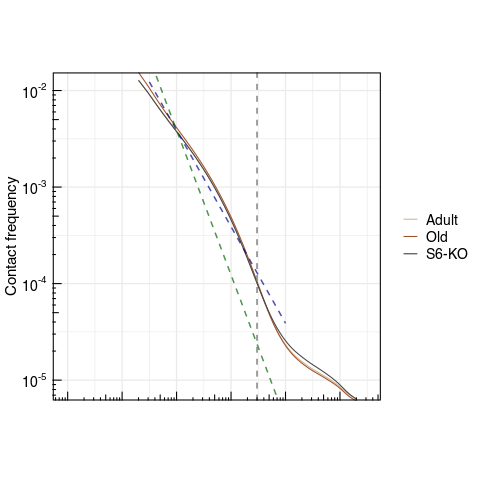

In [7]:
%%R

library(ggplot2)
library(scales)

cvd_clean <- cvd_combined %>%
  filter(is.finite(dist_bp), is.finite(balanced.avg.smoothed.agg),
         dist_bp > 0, balanced.avg.smoothed.agg > 0)
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'KO', 'S6-KO') 
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'WT', 'Adult') 

xmin <- min(cvd_clean$dist_bp)
xmax <- max(cvd_clean$dist_bp)
ymin <- min(cvd_clean$balanced.avg.smoothed.agg)
ymax <- max(cvd_clean$balanced.avg.smoothed.agg)

cvd_clean$condition <- factor(cvd_clean$condition, levels=c('Adult', 'Old', 'S6-KO'))

p1 <- ggplot(cvd_clean, aes(x = dist_bp, y = balanced.avg.smoothed.agg, color = condition)) +
  geom_line(size = 0.5) +
  
  geom_line(data = ref_line_1, aes(x = dist_bp, y = contact),
            color = "darkblue", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_line(data = ref_line_15, aes(x = dist_bp, y = contact),
            color = "darkgreen", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_vline(xintercept = 3e6, linetype = "dashed", color = "grey50", size = 0.7) +
  
  scale_y_log10(
    breaks = scales::log_breaks(base = 10, n = 5), 
    labels = scales::trans_format("log10", scales::math_format(10^.x)),
    limits = c(ymin, ymax),  
    expand = c(0, 0)          
  ) +
  scale_x_log10(
    breaks = c(1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9),
    labels = c(
      expression(10^3), expression(10^4), expression(10^5),
      expression(10^6), expression(10^7), expression(10^8),
      expression(10^9)
    ),
    limits = c(1e3, 3e8)  # Set explicit limits
  ) +
  annotation_logticks(sides = "bl") +
  
  labs(
    x = "",
    y = "Contact frequency",
    color = "Condition"
  ) +
  scale_colour_manual(values=c('tan', 'sienna', 'gray27')) +
  #scale_colour_manual(values=c('lightpink1', 'tan3', 'lightskyblue1')) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_blank(),
    axis.text.y       = element_text(size = 14, colour = "black"),
    axis.title.x      = element_text(size = 15, colour = "black"),
    axis.title.y      = element_text(size = 15, colour = "black"),
    legend.text       = element_text(size = 14),
    legend.title      = element_blank(),
    panel.border      = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio      = 1,
    #legend.position   = "none",
    plot.margin = margin(t = 7, r = 5, b = -7, l = 5, unit = "pt")
  )

p1

#ggsave("Figure1E-1_scalings_10kb.pdf", width = 5, height = 7, dpi=1200)

### Scalings ratios (10 kb)

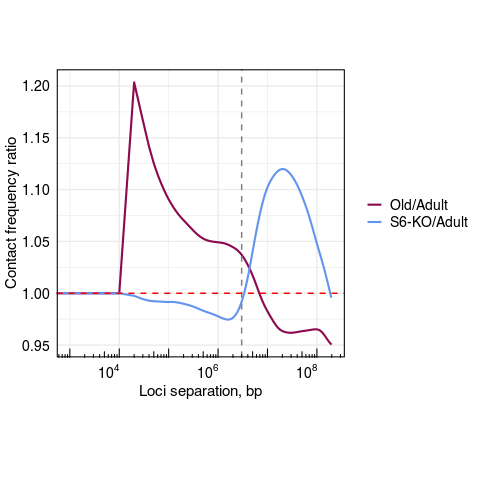

In [8]:
%%R

compute_normalized_ratio <- function(df, numerator, denominator) {
  num_data <- df %>% filter(condition == numerator)
  den_data <- df %>% filter(condition == denominator)
  
  merged <- inner_join(num_data, den_data, by = "dist_bp", suffix = c("_num", "_den")) %>%
    mutate(ratio = balanced.avg.smoothed.agg_num / balanced.avg.smoothed.agg_den)
  
  # Avoid division by zero or NaN
  merged$ratio[!is.finite(merged$ratio)] <- 1
  
  # Normalize to a reference point
  x_ref <- sort(unique(merged$dist_bp))[2]
  ref_value <- merged$ratio[which.min(abs(merged$dist_bp - x_ref))]
  merged <- merged %>%
    mutate(norm_ratio = ratio / ref_value,
           comp = paste0(numerator, "/", denominator))
  return(merged)
}

r1 <- compute_normalized_ratio(cvd_combined, "S6-KO", "Adult")
r2 <- compute_normalized_ratio(cvd_combined, "Old", "Adult")
ratios_df <- bind_rows(r1, r2)


p2 <- ggplot(ratios_df, aes(x = dist_bp, y = norm_ratio, color = comp)) +
  geom_line(size = 1) +  
  scale_x_log10(
    breaks = c(1e4, 1e6, 1e8),
    labels = c(
      expression(10^4), 
      expression(10^6), expression(10^8)
    ),
    limits = c(1e3, 2e8)  # Match limits from p1
  ) +
  geom_vline(xintercept = 3e6, linetype = "dashed", color = "grey50", size = 0.7) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red", size = 0.7) +
  annotation_logticks(
    sides = "b",         
  ) +
  labs(
    x = "Loci separation, bp", 
    y = "Contact frequency ratio",                 
    color = "Comp"              
  ) +
  scale_color_manual(values=c('deeppink4', 'cornflowerblue')) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(size = 14, colour = "black", hjust = 1),
    axis.text.y = element_text(size = 14, colour = "black"),
    axis.title.x = element_text(size = 15, colour = "black"),
    axis.title.y = element_text(size = 15, colour = "black"),
    legend.text = element_text(size = 14),
    legend.title = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio = 1,
    #legend.position = "none",
    plot.margin = margin(t = -7, r = 5, b = 5, l = 5, unit = "pt")
  )

p2

#ggsave("Figure1E-2_10kb.pdf", width = 5, height = 7, dpi=1200)

# Scalings at 1 kb coolers

In [21]:
combined_df = all_combined["1kb"]
combined_df.head(5)

,dist_bp,balanced.avg.smoothed.agg,condition
0,0,NaN,Adult
1,1000,NaN,Adult
2,2000,0.003212,Adult
3,3000,0.002999,Adult
4,4000,0.002757,Adult


### Calculate reference lines (s^(-1), s^(-3/2))

In [22]:
%%R
library(reticulate)
library(tidyverse)

cvd_combined <- reticulate::py_eval('combined_df')

x_ref <- 1e5
df_ref <- cvd_combined %>%
  group_by(dist_bp) %>%
  summarise(avg_contact = mean(balanced.avg.smoothed.agg, na.rm = TRUE))

y_ref <- approx(df_ref$dist_bp, df_ref$avg_contact, xout = x_ref)$y

x_vals <- 10^seq(4.5, 7, length.out = 100)
ref_line_1 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1) * (y_ref / (x_ref^-1)),
  label = "s^-1"
)
ref_line_15 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1.5) * (y_ref / (x_ref^-1.5)),
  label = "s^-3/2"
)


### Scaling plot (1 kb)


(`geom_line()`). 



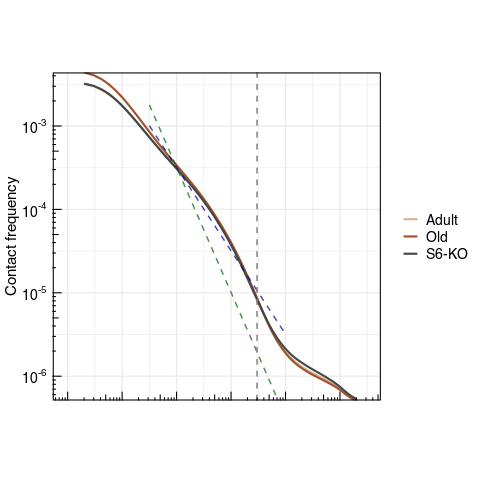

In [25]:
%%R

library(ggplot2)
library(scales)

cvd_clean <- cvd_combined %>%
  filter(is.finite(dist_bp), is.finite(balanced.avg.smoothed.agg),
         dist_bp > 0, balanced.avg.smoothed.agg > 0)
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'KO', 'S6-KO') 
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'WT', 'Adult') 

xmin <- min(cvd_clean$dist_bp)
xmax <- max(cvd_clean$dist_bp)
ymin <- min(cvd_clean$balanced.avg.smoothed.agg)
ymax <- max(cvd_clean$balanced.avg.smoothed.agg)

cvd_clean$condition <- factor(cvd_clean$condition, levels=c('Adult', 'Old', 'S6-KO'))

p1 <- ggplot(cvd_clean, aes(x = dist_bp, y = balanced.avg.smoothed.agg, color = condition)) +
  geom_line(size = 1) +
  
  geom_line(data = ref_line_1, aes(x = dist_bp, y = contact),
            color = "darkblue", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_line(data = ref_line_15, aes(x = dist_bp, y = contact),
            color = "darkgreen", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_vline(xintercept = 3e6, linetype = "dashed", color = "grey50", size = 0.7) +
  
  scale_y_log10(
    breaks = scales::log_breaks(base = 10, n = 5), 
    labels = scales::trans_format("log10", scales::math_format(10^.x)),
    limits = c(ymin, ymax),  
    expand = c(0, 0)          
  ) +
  scale_x_log10(
    breaks = c(1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9),
    labels = c(
      expression(10^3), expression(10^4), expression(10^5),
      expression(10^6), expression(10^7), expression(10^8),
      expression(10^9)
    ),
    limits = c(1e3, 3e8)  
  ) +
  annotation_logticks(sides = "bl") +
  
  labs(
    x = "",
    y = "Contact frequency",
    color = "Condition"
  ) +
  scale_colour_manual(values=c('tan', 'sienna', 'gray27')) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_blank(),
    axis.text.y       = element_text(size = 14, colour = "black"),
    axis.title.x      = element_text(size = 15, colour = "black"),
    axis.title.y      = element_text(size = 15, colour = "black"),
    legend.text       = element_text(size = 14),
    legend.title      = element_blank(),
    panel.border      = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio      = 1,
    #legend.position   = "none",
    plot.margin = margin(t = 7, r = 5, b = -7, l = 5, unit = "pt")
  )

p1

### Scaling plot (1 kb) - zoomed


(`geom_line()`). 

(`geom_line()`). 



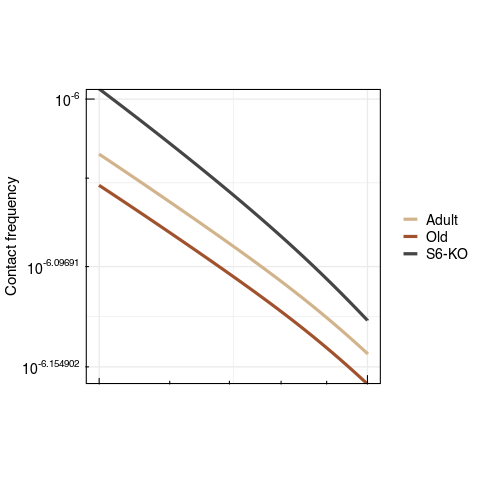

In [24]:
%%R

library(ggplot2)
library(scales)
library(dplyr)

cvd_clean <- cvd_combined %>%
  filter(
    is.finite(dist_bp),
    is.finite(balanced.avg.smoothed.agg),
    dist_bp > 0,
    balanced.avg.smoothed.agg > 0,
    dist_bp >= 5e7,
    dist_bp <= 1e8
  )

cvd_clean$condition <- replace(cvd_clean$condition, cvd_clean$condition == 'KO', 'S6-KO') 
cvd_clean$condition <- replace(cvd_clean$condition, cvd_clean$condition == 'WT', 'Adult') 

cvd_clean$condition <- factor(cvd_clean$condition, levels = c('Adult', 'Old', 'S6-KO'))

ymin <- min(cvd_clean$balanced.avg.smoothed.agg)
ymax <- max(cvd_clean$balanced.avg.smoothed.agg)

p1 <- ggplot(cvd_clean, aes(x = dist_bp, y = balanced.avg.smoothed.agg, color = condition)) +
  
  geom_line(size = 1.5) +
  
  geom_line(data = ref_line_1,
            aes(x = dist_bp, y = contact),
            color = "darkblue",
            linetype = "dashed",
            size = 0.7,
            inherit.aes = FALSE,
            alpha = 0.7) +
  
  geom_line(data = ref_line_15,
            aes(x = dist_bp, y = contact),
            color = "darkgreen",
            linetype = "dashed",
            size = 0.7,
            inherit.aes = FALSE,
            alpha = 0.7) +
  
  scale_y_log10(
    breaks = scales::log_breaks(base = 10, n = 5),
    labels = scales::trans_format("log10", scales::math_format(10^.x)),
    limits = c(ymin, ymax),
    expand = c(0, 0)
  ) +
  
  scale_x_log10(
    breaks = c(5e7, 1e8),
    labels = c(
      expression(5*10^7),
      expression(10^8)
    ),
    limits = c(5e7, 1e8)
  ) +
  
  annotation_logticks(sides = "bl") +
  
  labs(
    x = "",
    y = "Contact frequency",
    color = "Condition"
  ) +
  
  scale_colour_manual(values = c('tan', 'sienna', 'gray27')) +
  
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x      = element_blank(),
    axis.text.y      = element_text(size = 14, colour = "black"),
    axis.title.x     = element_text(size = 15, colour = "black"),
    axis.title.y     = element_text(size = 15, colour = "black"),
    legend.text      = element_text(size = 14),
    legend.title     = element_blank(),
    panel.border     = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio     = 1,
    plot.margin      = margin(t = 7, r = 5, b = -7, l = 5, unit = "pt")
  )

p1

#ggsave("Figure1E-1_scalings_1kb_5*10^7_10^8_bp.pdf", width = 5, height = 7, dpi=1200)

### Scalings ratios (1 kb)

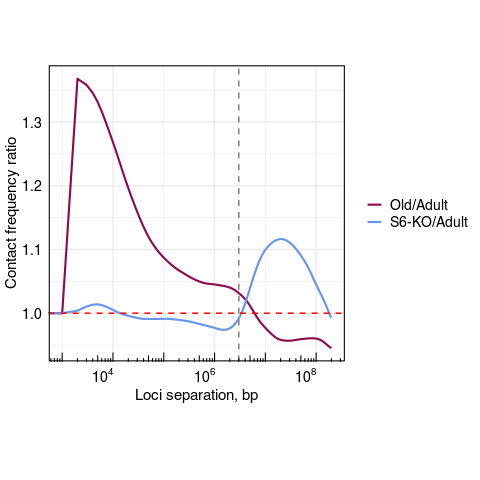

In [26]:
%%R

compute_normalized_ratio <- function(df, numerator, denominator) {
  num_data <- df %>% filter(condition == numerator)
  den_data <- df %>% filter(condition == denominator)
  
  merged <- inner_join(num_data, den_data, by = "dist_bp", suffix = c("_num", "_den")) %>%
    mutate(ratio = balanced.avg.smoothed.agg_num / balanced.avg.smoothed.agg_den)
  
  # Avoid division by zero or NaN
  merged$ratio[!is.finite(merged$ratio)] <- 1
  
  # Normalize to a reference point
  x_ref <- sort(unique(merged$dist_bp))[2]
  ref_value <- merged$ratio[which.min(abs(merged$dist_bp - x_ref))]
  merged <- merged %>%
    mutate(norm_ratio = ratio / ref_value,
           comp = paste0(numerator, "/", denominator))
  return(merged)
}

r1 <- compute_normalized_ratio(cvd_combined, "S6-KO", "Adult")
r2 <- compute_normalized_ratio(cvd_combined, "Old", "Adult")
ratios_df <- bind_rows(r1, r2)


p2 <- ggplot(ratios_df, aes(x = dist_bp, y = norm_ratio, color = comp)) +
  geom_line(size = 1) +  
  scale_x_log10(
    breaks = c(1e4, 1e6, 1e8),
    labels = c(
      expression(10^4), 
      expression(10^6), expression(10^8)
    ),
    limits = c(1e3, 2e8) 
  ) +
  geom_vline(xintercept = 3e6, linetype = "dashed", color = "grey50", size = 0.7) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red", size = 0.7) +
  annotation_logticks(
    sides = "b",         
  ) +
  labs(
    x = "Loci separation, bp",  
    y = "Contact frequency ratio",                 
    color = "Comp"               
  ) +
  scale_color_manual(values=c('deeppink4', 'cornflowerblue')) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(size = 14, colour = "black", hjust = 1),
    axis.text.y = element_text(size = 14, colour = "black"),
    axis.title.x = element_text(size = 15, colour = "black"),
    axis.title.y = element_text(size = 15, colour = "black"),
    legend.text = element_text(size = 14),
    legend.title = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio = 1,
    #legend.position = "none",
    plot.margin = margin(t = -7, r = 5, b = 5, l = 5, unit = "pt")
  )

p2

# Scalings across replicates

## Adult 

In [29]:
combined_df = all_combined["rep_adult"]
combined_df.head(5)

,dist_bp,balanced.avg.smoothed.agg,condition
0,0,NaN,Adult-1
1,10000,NaN,Adult-1
2,20000,0.013156,Adult-1
3,30000,0.009765,Adult-1
4,40000,0.007759,Adult-1


In [30]:
%%R
library(reticulate)
library(tidyverse)

cvd_combined <- reticulate::py_eval('combined_df')

x_ref <- 1e5
df_ref <- cvd_combined %>%
  group_by(dist_bp) %>%
  summarise(avg_contact = mean(balanced.avg.smoothed.agg, na.rm = TRUE))

y_ref <- approx(df_ref$dist_bp, df_ref$avg_contact, xout = x_ref)$y

x_vals <- 10^seq(4.5, 7, length.out = 100)
ref_line_1 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1) * (y_ref / (x_ref^-1)),
  label = "s^-1"
)
ref_line_15 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1.5) * (y_ref / (x_ref^-1.5)),
  label = "s^-3/2"
)



(`geom_line()`). 



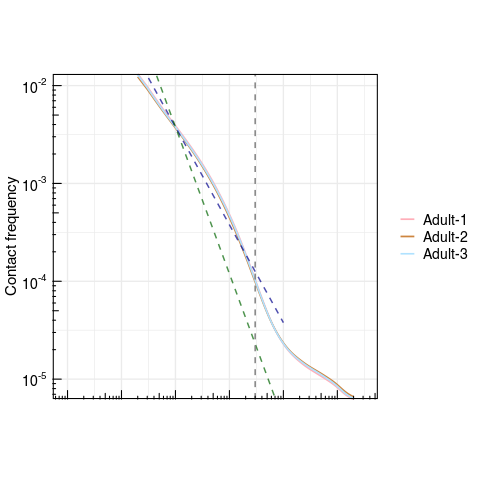

In [32]:
%%R

library(ggplot2)
library(scales)

cvd_clean <- cvd_combined %>%
  filter(is.finite(dist_bp), is.finite(balanced.avg.smoothed.agg),
         dist_bp > 0, balanced.avg.smoothed.agg > 0)

xmin <- min(cvd_clean$dist_bp)
xmax <- max(cvd_clean$dist_bp)
ymin <- min(cvd_clean$balanced.avg.smoothed.agg)
ymax <- max(cvd_clean$balanced.avg.smoothed.agg)

cvd_clean$condition <- factor(cvd_clean$condition, levels=c('Adult-1', 'Adult-2', 'Adult-3'))

p1 <- ggplot(cvd_clean, aes(x = dist_bp, y = balanced.avg.smoothed.agg, color = condition)) +
  geom_line(size = 0.8) +
  
  geom_line(data = ref_line_1, aes(x = dist_bp, y = contact),
            color = "darkblue", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_line(data = ref_line_15, aes(x = dist_bp, y = contact),
            color = "darkgreen", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_vline(xintercept = 3e6, linetype = "dashed", color = "grey50", size = 0.7) +
  
  scale_y_log10(
    breaks = scales::log_breaks(base = 10, n = 5), 
    labels = scales::trans_format("log10", scales::math_format(10^.x)),
    limits = c(ymin, ymax),  
    expand = c(0, 0)          
  ) +
  scale_x_log10(
    breaks = c(1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9),
    labels = c(
      expression(10^3), expression(10^4), expression(10^5),
      expression(10^6), expression(10^7), expression(10^8),
      expression(10^9)
    ),
    limits = c(1e3, 3e8)  # Set explicit limits
  ) +
  annotation_logticks(sides = "bl") +
  
  labs(
    x = "",
    y = "Contact frequency",
    color = "Condition"
  ) +
  #scale_colour_manual(values=c('tan', 'peru', 'burlywood')) +
  scale_colour_manual(values=c('lightpink1', 'tan3', 'lightskyblue1')) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_blank(),
    axis.text.y       = element_text(size = 14, colour = "black"),
    axis.title.x      = element_text(size = 15, colour = "black"),
    axis.title.y      = element_text(size = 15, colour = "black"),
    legend.text       = element_text(size = 14),
    legend.title      = element_blank(),
    panel.border      = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio      = 1,
    #legend.position   = "none",
    plot.margin = margin(t = 7, r = 5, b = -7, l = 5, unit = "pt")
  )

p1

#ggsave("Figure1_scalings_replicates_Adult.pdf", width = 5, height = 7, dpi=1200)

## S6-KO 

In [33]:
combined_df = all_combined["rep_s6ko"]
combined_df.head(5)

,dist_bp,balanced.avg.smoothed.agg,condition
0,0,NaN,S6-KO-1
1,10000,NaN,S6-KO-1
2,20000,0.013407,S6-KO-1
3,30000,0.009829,S6-KO-1
4,40000,0.007735,S6-KO-1


In [34]:
%%R
library(reticulate)
library(tidyverse)

cvd_combined <- reticulate::py_eval('combined_df')

x_ref <- 1e5
df_ref <- cvd_combined %>%
  group_by(dist_bp) %>%
  summarise(avg_contact = mean(balanced.avg.smoothed.agg, na.rm = TRUE))

y_ref <- approx(df_ref$dist_bp, df_ref$avg_contact, xout = x_ref)$y

x_vals <- 10^seq(4.5, 7, length.out = 100)
ref_line_1 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1) * (y_ref / (x_ref^-1)),
  label = "s^-1"
)
ref_line_15 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1.5) * (y_ref / (x_ref^-1.5)),
  label = "s^-3/2"
)



(`geom_line()`). 



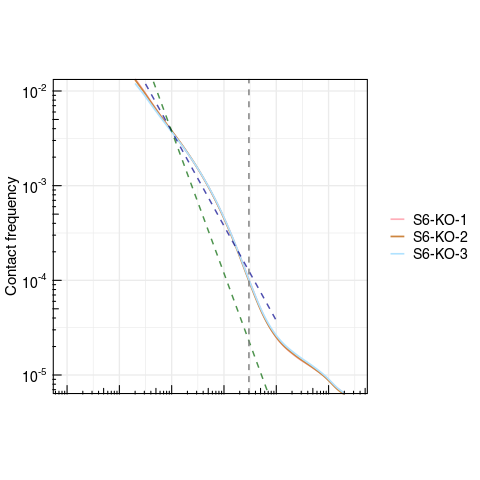

In [36]:
%%R

library(ggplot2)
library(scales)

cvd_clean <- cvd_combined %>%
  filter(is.finite(dist_bp), is.finite(balanced.avg.smoothed.agg),
         dist_bp > 0, balanced.avg.smoothed.agg > 0)
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'KO', 'S6-KO') 
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'WT', 'Adult') 

xmin <- min(cvd_clean$dist_bp)
xmax <- max(cvd_clean$dist_bp)
ymin <- min(cvd_clean$balanced.avg.smoothed.agg)
ymax <- max(cvd_clean$balanced.avg.smoothed.agg)

cvd_clean$condition <- factor(cvd_clean$condition, levels=c('S6-KO-1', 'S6-KO-2', 'S6-KO-3'))
#cvd_clean$condition <- factor(cvd_clean$condition, levels=c('S6-KO-1', 'S6-KO-2', 'S6-KO-3'))

p1 <- ggplot(cvd_clean, aes(x = dist_bp, y = balanced.avg.smoothed.agg, color = condition)) +
  geom_line(size = 0.8) +
  
  geom_line(data = ref_line_1, aes(x = dist_bp, y = contact),
            color = "darkblue", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_line(data = ref_line_15, aes(x = dist_bp, y = contact),
            color = "darkgreen", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_vline(xintercept = 3e6, linetype = "dashed", color = "grey50", size = 0.7) +
  
  scale_y_log10(
    breaks = scales::log_breaks(base = 10, n = 5), 
    labels = scales::trans_format("log10", scales::math_format(10^.x)),
    limits = c(ymin, ymax),  
    expand = c(0, 0)          
  ) +
  scale_x_log10(
    breaks = c(1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9),
    labels = c(
      expression(10^3), expression(10^4), expression(10^5),
      expression(10^6), expression(10^7), expression(10^8),
      expression(10^9)
    ),
    limits = c(1e3, 3e8)  # Set explicit limits
  ) +
  annotation_logticks(sides = "bl") +
  
  labs(
    x = "",
    y = "Contact frequency",
    color = "Condition"
  ) +
  scale_colour_manual(values=c('lightpink1', 'tan3', 'lightskyblue1')) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_blank(),
    axis.text.y       = element_text(size = 14, colour = "black"),
    axis.title.x      = element_text(size = 15, colour = "black"),
    axis.title.y      = element_text(size = 15, colour = "black"),
    legend.text       = element_text(size = 14),
    legend.title      = element_blank(),
    panel.border      = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio      = 1,
    #legend.position   = "none",
    plot.margin = margin(t = 7, r = 5, b = -7, l = 5, unit = "pt")
  )

p1

#ggsave("Figure1_scalings_replicates_S6-KO.pdf", width = 5, height = 7, dpi=1200)

## Old

In [37]:
combined_df = all_combined["rep_old"]
combined_df.head(5)

,dist_bp,balanced.avg.smoothed.agg,condition
0,0,NaN,Old-1
1,10000,NaN,Old-1
2,20000,0.016292,Old-1
3,30000,0.011622,Old-1
4,40000,0.008971,Old-1


In [38]:
%%R
library(reticulate)
library(tidyverse)

cvd_combined <- reticulate::py_eval('combined_df')

x_ref <- 1e5
df_ref <- cvd_combined %>%
  group_by(dist_bp) %>%
  summarise(avg_contact = mean(balanced.avg.smoothed.agg, na.rm = TRUE))

y_ref <- approx(df_ref$dist_bp, df_ref$avg_contact, xout = x_ref)$y

x_vals <- 10^seq(4.5, 7, length.out = 100)
ref_line_1 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1) * (y_ref / (x_ref^-1)),
  label = "s^-1"
)
ref_line_15 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1.5) * (y_ref / (x_ref^-1.5)),
  label = "s^-3/2"
)



(`geom_line()`). 



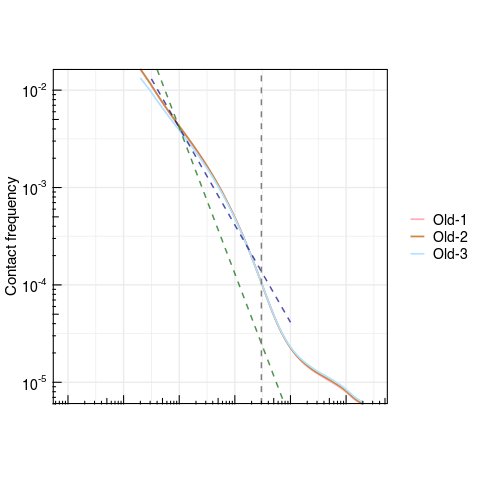

In [40]:
%%R

library(ggplot2)
library(scales)

cvd_clean <- cvd_combined %>%
  filter(is.finite(dist_bp), is.finite(balanced.avg.smoothed.agg),
         dist_bp > 0, balanced.avg.smoothed.agg > 0)
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'KO', 'S6-KO') 
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'WT', 'Adult') 

xmin <- min(cvd_clean$dist_bp)
xmax <- max(cvd_clean$dist_bp)
ymin <- min(cvd_clean$balanced.avg.smoothed.agg)
ymax <- max(cvd_clean$balanced.avg.smoothed.agg)

cvd_clean$condition <- factor(cvd_clean$condition, levels=c('Old-1', 'Old-2', 'Old-3'))

p1 <- ggplot(cvd_clean, aes(x = dist_bp, y = balanced.avg.smoothed.agg, color = condition)) +
  geom_line(size = 0.8) +
  
  geom_line(data = ref_line_1, aes(x = dist_bp, y = contact),
            color = "darkblue", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_line(data = ref_line_15, aes(x = dist_bp, y = contact),
            color = "darkgreen", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_vline(xintercept = 3e6, linetype = "dashed", color = "grey50", size = 0.7) +
  
  scale_y_log10(
    breaks = scales::log_breaks(base = 10, n = 5), 
    labels = scales::trans_format("log10", scales::math_format(10^.x)),
    limits = c(ymin, ymax),  
    expand = c(0, 0)          
  ) +
  scale_x_log10(
    breaks = c(1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9),
    labels = c(
      expression(10^3), expression(10^4), expression(10^5),
      expression(10^6), expression(10^7), expression(10^8),
      expression(10^9)
    ),
    limits = c(1e3, 3e8)  # Set explicit limits
  ) +
  annotation_logticks(sides = "bl") +
  
  labs(
    x = "",
    y = "Contact frequency",
    color = "Condition"
  ) +
  scale_colour_manual(values=c('lightpink1', 'tan3', 'lightskyblue1')) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_blank(),
    axis.text.y       = element_text(size = 14, colour = "black"),
    axis.title.x      = element_text(size = 15, colour = "black"),
    axis.title.y      = element_text(size = 15, colour = "black"),
    legend.text       = element_text(size = 14),
    legend.title      = element_blank(),
    panel.border      = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio      = 1,
    #legend.position   = "none",
    plot.margin = margin(t = 7, r = 5, b = -7, l = 5, unit = "pt")
  )

p1

#ggsave("Figure1_scalings_replicates_Old.pdf", width = 5, height = 7, dpi=1200)